In [1]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 17.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import spacy
nlp = spacy.load("en_core_web_md")

In [3]:
#PART B
#Tokenization and Vocabulary Exploration
import pandas as pd
import numpy as np
import spacy
from collections import Counter
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm")

sentences = [
    "I loved the movie.",
    "I did not love the movie.",
    "Book a flight from Almaty to Astana.",
    "Turn the light on.",
    "Can you turn the light off?",
    "Apple released a new device in 2025.",
    "lol this movie was crazy good",
    "Open the door now."
]

rows = []

for text in sentences:
    doc = nlp(text)
    rows.append({
        "text": text,
        "tokens": [t.text for t in doc],
        "lower": [t.text.lower() for t in doc],
        "filtered": [t.text.lower() for t in doc if not t.is_punct and not t.is_stop],
        "lemmas": [t.lemma_.lower() for t in doc if not t.is_punct]
    })

df = pd.DataFrame(rows)
print(df)

all_tokens = []
for text in sentences:
    doc = nlp(text)
    for token in doc:
        if not token.is_punct:
            all_tokens.append(token.text.lower())

print("Total tokens:", len(all_tokens))
print("Unique tokens:", len(set(all_tokens)))
print("Top 5:", Counter(all_tokens).most_common(5))

                                   text  \
0                    I loved the movie.   
1             I did not love the movie.   
2  Book a flight from Almaty to Astana.   
3                    Turn the light on.   
4           Can you turn the light off?   
5  Apple released a new device in 2025.   
6         lol this movie was crazy good   
7                    Open the door now.   

                                           tokens  \
0                       [I, loved, the, movie, .]   
1              [I, did, not, love, the, movie, .]   
2  [Book, a, flight, from, Almaty, to, Astana, .]   
3                       [Turn, the, light, on, .]   
4            [Can, you, turn, the, light, off, ?]   
5  [Apple, released, a, new, device, in, 2025, .]   
6            [lol, this, movie, was, crazy, good]   
7                       [Open, the, door, now, .]   

                                            lower  \
0                       [i, loved, the, movie, .]   
1              [i, did, not,

In [4]:
# B3. Word-vector exploration

import pandas as pd
import numpy as np
import spacy


nlp = spacy.load("en_core_web_md")


word_groups = {
    "emotions": ["happy", "sad", "angry"],
    "movies": ["actor", "film", "director"],
    "travel": ["plane", "train", "airport"],
    "translation": ["language", "english", "kazakh"]
}


def get_nearest_neighbors(word, n=5):
    if not nlp.vocab.has_vector(word):
        return []

    vector = np.array([nlp.vocab.get_vector(word)], dtype="float32")
    result = nlp.vocab.vectors.most_similar(vector, n=n + 1)

    keys = result[0][0]
    neighbors = []

    for key in keys:
        similar_word = nlp.vocab.strings[int(key)]
        if similar_word.lower() != word.lower():
            neighbors.append(similar_word)
        if len(neighbors) == n:
            break

    return neighbors


rows = []

for group, words in word_groups.items():
    for word in words:
        has_vector = nlp.vocab.has_vector(word)
        neighbors = get_nearest_neighbors(word)

        rows.append({
            "Semantic Group": group,
            "Word": word,
            "Vector Exists": has_vector,
            "Nearest Neighbors": ", ".join(neighbors)
        })

df = pd.DataFrame(rows)




df

,Semantic Group,Word,Vector Exists,Nearest Neighbors
0,emotions,happy,True,"Casual, Admire, Adventurous, FORWARD-LOOKING, ..."
1,emotions,sad,True,"hopeless, DEPRESSING, Pathetic, Sorrowful, FOR..."
2,emotions,angry,True,"DISTURBED, anxious, Deathly, Hooked, Pooped"
3,movies,actor,True,"Swashbuckler, Reprising, ANTIHERO, charactors,..."
4,movies,film,True,"starred, musical, QUIRKY, comedies, exhilerating"
5,movies,director,True,"Broadcaster, Editor-At-Large, adviser, adviser..."
6,travel,plane,True,"CONNECTOR, PASSAGEWAY, Recessed, ultrasonic, R..."
7,travel,train,True,"Freeways, thoroughfare, causeway, BURDEN, tran..."
8,travel,airport,True,"luxury, Flights, stockists, SHOPPING, STORE"
9,translation,language,True,"morphosyntactic, universals, orthographical, p..."


def get_nearest_neighbors(word, n=5):

Что делает функция:

Проверяет, есть ли у слова вектор
Берёт его числовое представление
Ищет n самых похожих слов в пространстве векторов
Убирает само исходное слово
Возвращает список ближайших слов

In [5]:

# Part C: Static Embedding Baseline

import re
import numpy as np
import pandas as pd
import spacy

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# C1. Load dataset

dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("Train size:", len(train_df))
print("Test size:", len(test_df))


print("\nPositive examples:")
for text in train_df[train_df["label"] == 1]["text"].head(2):
    print(text[:400])
    print("-"*80)

print("\nNegative examples:")
for text in train_df[train_df["label"] == 0]["text"].head(2):
    print(text[:400])
    print("-"*80)

train_df["len"] = train_df["text"].apply(lambda x: len(x.split()))
print("\nAverage review length:", train_df["len"].mean())


# C2. Preprocessing

"""
Explanation:
We lowercase text to normalize words.
We remove punctuation and HTML because they are not useful.
We keep stopwords because words like "not" are important for sentiment.
We do not lemmatize to keep preprocessing simple for baseline.
"""

nlp = spacy.load("en_core_web_md")

def preprocess(text):
    text = re.sub(r"<.*?>", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.split()

train_df["tokens"] = train_df["text"].apply(preprocess)
test_df["tokens"] = test_df["text"].apply(preprocess)


# C3. Review → vector (mean pooling)

def to_vector(tokens):
    vecs = [nlp.vocab.get_vector(t) for t in tokens if nlp.vocab.has_vector(t)]
    if len(vecs) == 0:
        return np.zeros(nlp.vocab.vectors_length)
    return np.mean(vecs, axis=0)

train_sample = train_df.sample(8000, random_state=42)
test_sample = test_df.sample(3000, random_state=42)

X = np.vstack(train_sample["tokens"].apply(to_vector))
y = train_sample["label"].values

X_test = np.vstack(test_sample["tokens"].apply(to_vector))
y_test = test_sample["label"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# C4. Train model


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# C5. Evaluation
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

print("\nAccuracy:")
print("Train:", accuracy_score(y_train, train_pred))
print("Validation:", accuracy_score(y_val, val_pred))
print("Test:", accuracy_score(y_test, test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report:")
print(classification_report(y_test, test_pred))


results = test_sample.copy()
results["pred"] = test_pred
results["correct"] = results["label"] == results["pred"]

results["true"] = results["label"].map({0:"Negative",1:"Positive"})
results["predicted"] = results["pred"].map({0:"Negative",1:"Positive"})

print("\n===== Correct examples =====")
for _, row in results[results["correct"]].head(5).iterrows():
    print("True:", row["true"], "| Pred:", row["predicted"])
    print(row["text"][:500])
    print("-"*100)

print("\n===== Incorrect examples =====")
for _, row in results[~results["correct"]].head(5).iterrows():
    print("True:", row["true"], "| Pred:", row["predicted"])
    print(row["text"][:500])

    if row["true"] == "Positive":
        print("Reason: contains negative words, model confused due to averaging.")
    else:
        print("Reason: mixed or sarcastic text, model cannot capture context.")

    print("-"*100)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 25000
Test size: 25000

Positive examples:
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-
--------------------------------------------------------------------------------
Zentropa is the most original movie I've seen in years. If you like unique thrillers that are influenced by film noir, then this is just the right cure for all of those Hollywood summer blockbusters clogging the theaters these days. Von Trier's follow-ups like Breaking the Waves have gotten more acclaim, but this is really his best work. It is flashy without being distracting and offers the perfec
--------------------------------------------------------------

* Проблема 1: смешанные отзывы
* Проблема 2: отрицание (negation)
* Проблема 3: сложные тексты
*Модель использует mean pooling (усреднение)
Это значит:
теряется порядок слов
теряется структура предложения

In [ ]:

# Part D: Stress Test the Model


import numpy as np
import pandas as pd

# Contrast set: 12+ examples
contrast_examples = [
    # Negation examples
    ("negation", "The movie was good."),
    ("negation", "The movie was not good."),
    ("negation", "I liked this film."),
    ("negation", "I hardly liked this film."),
    ("negation", "The acting was enjoyable."),
    ("negation", "The acting was not enjoyable."),

    # Word-order examples
    ("word order", "Dog bites man."),
    ("word order", "Man bites dog."),
    ("word order", "Flights from Astana to Almaty."),
    ("word order", "Flights from Almaty to Astana."),
    ("word order", "The hero defeats the villain."),
    ("word order", "The villain defeats the hero."),

    # Ambiguity / word-sense examples
    ("ambiguity", "He went to the bank to get money."),
    ("ambiguity", "He sat by the river bank."),
    ("ambiguity", "Book a flight for tomorrow."),
    ("ambiguity", "Read a book about history."),

    # Translation / bilingual meaning examples
    ("translation", "The word alma means apple in Kazakh."),
    ("translation", "Almaty is a city, not only a word related to apple."),
    ("translation", "I love English movies."),
    ("translation", "I love translating English movies into Kazakh."),

    # Own choice
    ("own choice", "This movie is sick."),
    ("own choice", "This movie made me sick."),
    ("own choice", "The plot was surprisingly bad."),
    ("own choice", "The plot was not surprisingly bad.")
]

contrast_df = pd.DataFrame(contrast_examples, columns=["category", "sentence"])

contrast_df["tokens"] = contrast_df["sentence"].apply(preprocess)

X_contrast = np.vstack(contrast_df["tokens"].apply(to_vector))

contrast_df["prediction"] = model.predict(X_contrast)
contrast_df["predicted_label"] = contrast_df["prediction"].map({
    0: "Negative",
    1: "Positive"
})

if hasattr(model, "predict_proba"):
    probs = model.predict_proba(X_contrast)
    contrast_df["negative_probability"] = probs[:, 0]
    contrast_df["positive_probability"] = probs[:, 1]

contrast_df[[
    "category",
    "sentence",
    "predicted_label",
    "negative_probability",
    "positive_probability"
]]

,category,sentence,predicted_label,negative_probability,positive_probability
0,negation,The movie was good.,Negative,0.622803,0.377197
1,negation,The movie was not good.,Negative,0.824859,0.175141
2,negation,I liked this film.,Positive,0.013769,0.986231
3,negation,I hardly liked this film.,Positive,0.303062,0.696938
4,negation,The acting was enjoyable.,Negative,0.556393,0.443607
5,negation,The acting was not enjoyable.,Negative,0.790788,0.209212
6,word order,Dog bites man.,Negative,0.987026,0.012974
7,word order,Man bites dog.,Negative,0.987026,0.012974
8,word order,Flights from Astana to Almaty.,Negative,0.999804,0.000196
9,word order,Flights from Almaty to Astana.,Negative,0.999804,0.000196


Эта таблица показывает слабости модели:

❌ не понимает порядок слов
❌ не понимает отрицание
❌ не понимает контекст
❌ не различает значения слов

Dataset size: 50

First 10 pairs:
                 source             target
0          good morning        kaiyrly tan
1             thank you             rahmet
2                 hello              salem
3           how are you           qalaysyn
4             i am fine       men jaqsymyn
5     what is your name     senin atyn kim
6      my name is damir   menin atym damir
7  where is the station        beket qaida
8         book a ticket     bilet bron dau
9           i need help  magan komek kerek

Example tokenized pair:
['<SOS>', 'good', 'morning', '<EOS>']
['<SOS>', 'kaiyrly', 'tan', '<EOS>']

Source length stats:
 count    50.000000
mean      5.220000
std       0.815413
min       3.000000
25%       5.000000
50%       5.000000
75%       6.000000
max       7.000000
Name: src_len, dtype: float64

Target length stats:
 count    50.000000
mean      4.540000
std       0.787919
min       3.000000
25%       4.000000
50%       4.000000
75%       5.000000
max       6.000000
Name: tgt_len

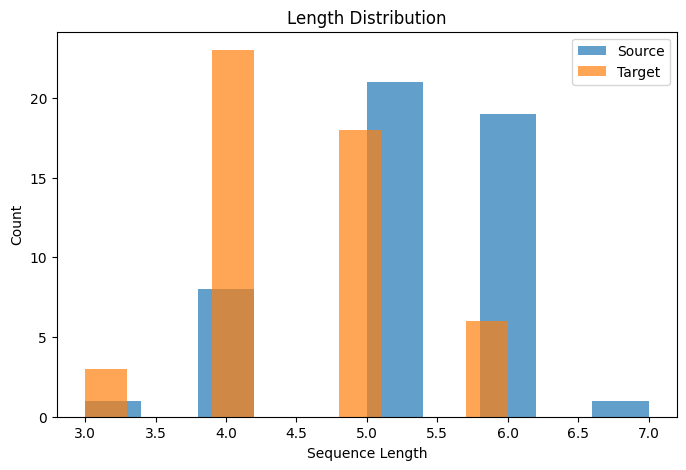


Source vocab size: 97
Target vocab size: 103

Padded source batch:
 tensor([[ 1,  3,  4,  2,  0],
        [ 1,  5,  6,  2,  0],
        [ 1,  7,  2,  0,  0],
        [ 1,  8,  9,  6,  2],
        [ 1, 10, 11, 12,  2]])

Padded target batch:
 tensor([[1, 3, 4, 2],
        [1, 5, 2, 0],
        [1, 6, 2, 0],
        [1, 7, 2, 0],
        [1, 8, 9, 2]])

Original source tokens:
['<SOS>', 'good', 'morning', '<EOS>']
['<SOS>', 'thank', 'you', '<EOS>']
['<SOS>', 'hello', '<EOS>']
['<SOS>', 'how', 'are', 'you', '<EOS>']
['<SOS>', 'i', 'am', 'fine', '<EOS>']

Original target tokens:
['<SOS>', 'kaiyrly', 'tan', '<EOS>']
['<SOS>', 'rahmet', '<EOS>']
['<SOS>', 'salem', '<EOS>']
['<SOS>', 'qalaysyn', '<EOS>']
['<SOS>', 'men', 'jaqsymyn', '<EOS>']

--- Explanation: Padding ---
Padding is needed because sentences have different lengths.
We add <PAD> tokens so all sequences in a batch have the same size.

--- Explanation: Why averaging is not enough ---
Averaging word vectors loses order and sequenc

In [ ]:

# Part E: Translation Mini-Track (FULL)
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.nn.utils.rnn import pad_sequence

pairs = [
    ("good morning", "kaiyrly tan"),
    ("thank you", "rahmet"),
    ("hello", "salem"),
    ("how are you", "qalaysyn"),
    ("i am fine", "men jaqsymyn"),
    ("what is your name", "senin atyn kim"),
    ("my name is damir", "menin atym damir"),
    ("where is the station", "beket qaida"),
    ("book a ticket", "bilet bron dau"),
    ("i need help", "magan komek kerek"),
    ("how much is it", "bul qansha turady"),
    ("i do not understand", "men tusinbeimin"),
    ("please repeat", "qaitalap aytynyz"),
    ("where is the airport", "auejai qaida"),
    ("i want water", "men su ishkim keledi"),
    ("this movie is good", "bul film jaqsy"),
    ("the weather is cold", "aua raiy suyuq"),
    ("i am going home", "men uige bara jatyrmyn"),
    ("open the door", "esikti ash"),
    ("close the window", "terezheni jap"),
    ("see you tomorrow", "erten kezdesemiz"),
    ("good night", "qaiyrly tun"),
    ("i love kazakhstan", "men qazaqstandy jaqsy koremin"),
    ("where are you from", "sen qaidan bolasyn"),
    ("i am from almaty", "men almatydan bolamyn"),
    ("call me later", "magan keiin qongyrau shal"),
    ("wait a minute", "bir minut kut"),
    ("i am hungry", "men ashpyryn"),
    ("i am tired", "men sharshadym"),
    ("have a nice day", "kuniniz satty otsin"),
    ("go straight", "tura juryngiz"),
    ("turn left", "solga burynyz"),
    ("turn right", "onga burynyz"),
    ("where is the bus stop", "avtobus ayaldamasy qaida"),
    ("i need a taxi", "magan taksi kerek"),
    ("this is my friend", "bul menin dosym"),
    ("i study at university", "men universitetde oqimyn"),
    ("i like this lesson", "magan bul sabaq unaidy"),
    ("the task is difficult", "tapsyrma qiyn"),
    ("the task is easy", "tapsyrma onai"),
    ("can you help me", "magan komektese alasyn ba"),
    ("i speak english", "men agylshynsha soileimin"),
    ("i speak kazakh", "men qazaqsha soileimin"),
    ("translate this sentence", "bul soilemdi audar"),
    ("write your answer", "jauabyndy jaz"),
    ("read the text", "matindi oqy"),
    ("listen carefully", "muqiyat tynda"),
    ("start the program", "bagdarlamany basta"),
    ("stop the program", "bagdarlamany toqtat"),
    ("save the file", "faildy saqta")
]

df = pd.DataFrame(pairs, columns=["source", "target"])

print("Dataset size:", len(df))
print("\nFirst 10 pairs:")
print(df.head(10))


# Tokenization + Special Tokens

def tokenize(text):
    return text.lower().split()

def add_special(tokens):
    return ["<SOS>"] + tokens + ["<EOS>"]

df["src_tokens"] = df["source"].apply(lambda x: add_special(tokenize(x)))
df["tgt_tokens"] = df["target"].apply(lambda x: add_special(tokenize(x)))

print("\nExample tokenized pair:")
print(df.iloc[0]["src_tokens"])
print(df.iloc[0]["tgt_tokens"])


# Sequence length analysis

df["src_len"] = df["src_tokens"].apply(len)
df["tgt_len"] = df["tgt_tokens"].apply(len)

print("\nSource length stats:\n", df["src_len"].describe())
print("\nTarget length stats:\n", df["tgt_len"].describe())


plt.figure(figsize=(8,5))
plt.hist(df["src_len"], alpha=0.7, label="Source")
plt.hist(df["tgt_len"], alpha=0.7, label="Target")
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Length Distribution")
plt.legend()
plt.show()


def build_vocab(token_lists):
    vocab = {"<PAD>":0, "<SOS>":1, "<EOS>":2}
    for tokens in token_lists:
        for t in tokens:
            if t not in vocab:
                vocab[t] = len(vocab)
    return vocab

src_vocab = build_vocab(df["src_tokens"])
tgt_vocab = build_vocab(df["tgt_tokens"])

print("\nSource vocab size:", len(src_vocab))
print("Target vocab size:", len(tgt_vocab))


# Convert to IDs


def to_ids(tokens, vocab):
    return [vocab[t] for t in tokens]

df["src_ids"] = df["src_tokens"].apply(lambda x: to_ids(x, src_vocab))
df["tgt_ids"] = df["tgt_tokens"].apply(lambda x: to_ids(x, tgt_vocab))

# Padding example (batch)

batch = df.head(5)

src_tensors = [torch.tensor(x) for x in batch["src_ids"]]
tgt_tensors = [torch.tensor(x) for x in batch["tgt_ids"]]

src_padded = pad_sequence(src_tensors, batch_first=True, padding_value=0)
tgt_padded = pad_sequence(tgt_tensors, batch_first=True, padding_value=0)

print("\nPadded source batch:\n", src_padded)
print("\nPadded target batch:\n", tgt_padded)

print("\nOriginal source tokens:")
for t in batch["src_tokens"]:
    print(t)

print("\nOriginal target tokens:")
for t in batch["tgt_tokens"]:
    print(t)


print("\n--- Explanation: Padding ---")
print("Padding is needed because sentences have different lengths.")
print("We add <PAD> tokens so all sequences in a batch have the same size.")

print("\n--- Explanation: Why averaging is not enough ---")
print("Averaging word vectors loses order and sequence information.")
print("Translation requires generating words step-by-step.")
print("Models like RNN/GRU/LSTM keep context using hidden states.")

Padded batch показывает, как предложения превращаются в числа одинаковой длины.
Padding нужен, потому что нейросети обычно обучаются батчами, а в одном батче все последовательности должны иметь одинаковую длину.

# Part F. Written Answers

## General questions

### 1. What is the difference between a token, a type, and a vocabulary?
A token is one word in one position in the text.
A type is one unique word form.
A vocabulary is the full set of unique words in the dataset.

### 2. Why can pretrained embeddings help when the dataset is not very large?
Pretrained embeddings already contain useful semantic information from large text data.
Because of this, the model can learn better even with a smaller dataset.

### 3. Why is average pooling over word vectors order-invariant?
Because averaging does not use word position.
If the same words appear in a different order, the average can stay the same.

### 4. Give one example where static embeddings are useful and one where they are not enough.
They are useful for simple sentiment classification.
They are not enough for translation or tasks where word order is very important.

### 5. What is the difference between a word embedding and a sentence embedding?
A word embedding represents one word as a vector.
A sentence embedding represents a whole sentence as one vector.

### 6. Why can the word "bank" cause trouble for static embeddings?
Because the word "bank" can have different meanings.
It can mean a money bank or a river bank.

### 7. If two sentences contain the same words in a different order, what will happen to a plain average embedding? Why is that a problem?
The average embedding can become the same or very similar.
This is a problem because the meaning can be very different.

### 8. What would you want the hidden state of an RNN to remember while reading a sentence?
I want it to remember previous words, negation, word order, and local context.

## Translation mini-track questions

### 9. Why do sequence-to-sequence models need <SOS> and <EOS> tokens?
They show where the sentence starts and where it ends.
This helps the model begin and stop generation correctly.

### 10. Why do source and target sentences usually need padding in batches?
Because sentences have different lengths.
Padding makes them the same length for batch processing.

### 11. Why is translation a sequence-to-sequence problem rather than a simple classification problem?
Because the output is not one label.
The output is a new ordered sequence of words in another language.

### Definitions for Part F

**Token** = one word unit in text.

**Type** = one unique word form.

**Vocabulary** = all unique words in the dataset.

**Embedding** = numeric representation of text.

**Sentence embedding** = one vector for a whole sentence.

**Order-invariant** = not affected by word order.

**RNN** = model that reads text step by step.

**Hidden state** = internal memory of an RNN.

**Sequence-to-sequence** = task with sequence input and sequence output.